## SDE Convergence Analysis: Euler–Maruyama, Milstein

 This notebook follows the extended workflow:
 1. Start with a simple stochastic differential equation (SDE)
    - Geometric Brownian Motion (GBM) with a known analytical solution.
 2. Implement an Euler–Maruyama SDE solver
    - Add the noise term explicitly.
    - Validate strong and weak convergence.
 3. Extend to a higher-order method (2nd-order Euler)
    - Milstein method as a "2nd-order Euler" for GBM.
    - Compare convergence to Euler–Maruyama.
 4. Investigate how noise affects higher-order accuracy
    - Replace Gaussian increments with skew-normal (variance, skewness, 
      kurtosis) increments and examine moment effects.

In [1]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import time

---
### Setup: Geometric Brownian Motion (GBM)

Setup with SDE:

$$dX_t = \mu X_t\,dt + \sigma X_t\,dW_t,\qquad X_0 = x_0,$$

with closed-form terminal solution

$$X_T = X_0 \exp\left( (\mu - \tfrac{1}{2}\sigma^2)T + \sigma W_T \right),$$

where $W_T \sim N(0, T)$.

This gives us:
 - An **exact path-level distribution** at time T.
 - Closed-form **mean** and **variance**:
   $$
   \mathbb{E}[X_T] = x_0 e^{\mu T}, \quad
   \mathrm{Var}(X_T) = x_0^2 e^{2\mu T}\left(e^{\sigma^2 T} - 1\right).
   $$

 I'll use these to benchmark both strong and weak convergence.

In [2]:
# Global SDE parameters
x0 = 1.0      # initial value X_0
mu = 0.2      # drift
sigma = 0.4   # diffusion
T = 1.0       # final time horizon


# Exact GBM helpers
def gbm_exact_terminal_from_WT(x0, mu, sigma, T, W_T):
    """
    Exact GBM terminal value given the realized Brownian motion W_T.

    X_T = X_0 * exp( (mu - 0.5 * sigma^2)*T + sigma * W_T )
    """
    return x0 * np.exp((mu - 0.5 * sigma**2) * T + sigma * W_T)

def gbm_exact_mean_var(x0, mu, sigma, T):
    """
    Exact mean and variance of X_T for GBM.
    """
    mean = x0 * np.exp(mu * T)
    var = (x0**2) * np.exp(2 * mu * T) * (np.exp(sigma**2 * T) - 1.0)
    return mean, var

### Noise Increment Generators

Simulate Brownian increments:

$$\Delta W_n \sim N(0, \Delta t).$$

In [3]:
def draw_increment(dt, rng, noise_mode="gaussian", skew_alpha=0.0):
    """
    Draw a single Brownian-like increment ΔW with variance dt.

    Parameters
    ----------
    dt : float
        Time step size (so Var[ΔW] should be dt).
    rng : np.random.Generator
        Random number generator.
    noise_mode : {"gaussian", "skewnormal"}
        - "gaussian": standard Brownian increment N(0, dt)
        - "skewnormal": a skew-normal-based increment, rescaled to mean ~0, var ~dt
    skew_alpha : float
        Skewness parameter for skew-normal case (0 => symmetric / Gaussian-like).
    """
    if noise_mode == "gaussian":
        # Standard Brownian increment with correct variance
        return rng.normal(0.0, math.sqrt(dt))

    elif noise_mode == "skewnormal":
        # Azzalini-type skew-normal construction with parameter alpha.
        # Standardize to mean 0, var dt.
        alpha = float(skew_alpha)
        if alpha == 0.0:
            # Degenerates to Gaussian if alpha = 0
            return rng.normal(0.0, math.sqrt(dt))

        # Generate skew-normal-ish variate with unit variance (before rescaling)
        Z = rng.normal(0.0, 1.0)
        U = rng.normal(0.0, 1.0)
        delta = alpha / math.sqrt(1.0 + alpha**2)

        # Y ~ skew-normal-like variable (not yet standardized)
        Y = delta * abs(Z) + math.sqrt(1.0 - delta**2) * U

        # Theoretical mean/var for SN(0,1,alpha)
        mean_Y = delta * math.sqrt(2.0 / math.pi)
        var_Y = 1.0 - 2.0 * delta**2 / math.pi

        # Standardize to mean 0 and var 1, then scale to var dt
        Y_std = (Y - mean_Y) / math.sqrt(var_Y)
        return Y_std * math.sqrt(dt)

    else:
        raise ValueError(f"Unknown noise_mode: {noise_mode}")

def sample_increment_moments(dt, rng, n=200_000, noise_mode="gaussian", skew_alpha=0.0):
    """
    Empirically estimate mean, variance, skewness, and excess kurtosis
    of ΔW under the chosen noise model.
    """
    vals = np.array([draw_increment(dt, rng, noise_mode, skew_alpha) for _ in range(n)])

    mean = float(vals.mean())
    var = float(vals.var(ddof=1))

    # Centered moments
    centered = vals - mean
    m2 = float(np.mean(centered**2))
    m3 = float(np.mean(centered**3))
    m4 = float(np.mean(centered**4))

    # Skewness and excess kurtosis (Fisher definition: kurt - 3)
    skew = m3 / (m2**1.5 + 1e-18)
    excess_kurt = m4 / (m2**2 + 1e-18) - 3.0

    return mean, var, skew, excess_kurt

---
### Euler–Maruyama and Milstein Methods

For the GBM SDE:
 - Drift: $a(x) = \mu x$
 - Diffusion: $b(x) = \sigma x$

Milstein has **strong order 1** (under regularity conditions), versus **strong order 1/2** for EM.

#### Euler–Maruyama (EM)

$$X_{n+1} = X_n + a(X_n)\Delta t + b(X_n)\Delta W_n.$$

In [4]:
def euler_step(x, dt, dW):
    """
    One Euler–Maruyama update step for GBM.

    x_{n+1} = x_n + mu*x_n*dt + sigma*x_n*dW
    """
    return x + mu * x * dt + sigma * x * dW

def euler_simulate(x0, N, rng, noise_mode="gaussian", skew_alpha=0.0):
    """
    Simulate a single GBM path with N time steps using Euler–Maruyama.
    """
    dt = T / N
    x = float(x0)
    for _ in range(N):
        dW = draw_increment(dt, rng, noise_mode, skew_alpha)
        x = euler_step(x, dt, dW)
    return x

#### Milstein (2nd-order Euler for SDEs)

$$X_{n+1} = X_n + a(X_n)\Delta t + b(X_n)\Delta W_n +
\tfrac12 b(X_n)b'(X_n)\left((\Delta W_n)^2 - \Delta t\right),$$

where $b'(x) = \sigma$ for GBM.

In [5]:
def milstein_step(x, dt, dW):
    """
    One Milstein update step for GBM.

    Adds the correction: 0.5 * b(x) * b'(x) * ((dW)^2 - dt)
    with b(x) = sigma*x, b'(x) = sigma.
    """
    return (x
            + mu * x * dt
            + sigma * x * dW
            + 0.5 * (sigma * x) * sigma * (dW**2 - dt))

def milstein_simulate(x0, N, rng, noise_mode="gaussian", skew_alpha=0.0):
    """
    Simulate a single GBM path with N time steps using Milstein method.
    """
    dt = T / N
    x = float(x0)
    for _ in range(N):
        dW = draw_increment(dt, rng, noise_mode, skew_alpha)
        x = milstein_step(x, dt, dW)
    return x

---
### Strong and Weak Error Diagnostics + Runtime

The following sections contain logic to:
  - Compute **strong error curves** for EM and Milstein.
  - Compute **weak error curves** (for expectation of X_T).
  - Build a **runtime vs accuracy table**.

#### Strong Error
For each path:
  - Draw a sequence of increments $\{\Delta W_n\}$.
  - Use them to drive the **numerical scheme**.
  - Sum them to obtain $W_T$, then compute **exact GBM X_T**.
  - Measure $|X_T^{\text{num}} - X_T^{\text{exact}}|$.
  - Average over many paths.

In [6]:
def strong_error_curve(
    method,
    Ns,
    M=1000,
    noise_mode="gaussian",
    skew_alpha=0.0,
    seed=123,
):
    """
    Compute strong error E[ |X_T^num - X_T^exact| ] for a sequence of step counts Ns.

    method : "euler" or "milstein"
    Ns     : iterable of ints (number of steps per path)
    M      : number of Monte Carlo paths per N
    noise_mode, skew_alpha : passed to draw_increment
    """
    rng = np.random.default_rng(seed)
    dts = []
    errors = []

    for N in Ns:
        dt = T / N
        path_errors = []
        for _ in range(M):
            # Generate increments once and reuse for both num path and exact solution
            dWs = np.array([draw_increment(dt, rng, noise_mode, skew_alpha) for _ in range(N)])
            W_T = dWs.sum()
            X_exact = gbm_exact_terminal_from_WT(x0, mu, sigma, T, W_T)

            # Evolve numerical solution with same increments
            x = float(x0)
            for dW in dWs:
                if method == "euler":
                    x = euler_step(x, dt, dW)
                elif method == "milstein":
                    x = milstein_step(x, dt, dW)
                else:
                    raise ValueError(f"Unknown method: {method}")

            path_errors.append(abs(x - X_exact))

        dts.append(dt)
        errors.append(np.mean(path_errors))

    return np.array(dts), np.array(errors)

#### Weak Error
For each step size:
  - Simulate many paths with standard Gaussian dW.
  - Compare the sample mean $\mathbb{E}[X_T^{\text{num}}]$ to exact mean $\mathbb{E}[X_T]$.

In [27]:
cum_x = {}

def weak_error_curve(method, Ns, M=8000, seed=999):
    """
    Compute weak error |E[X_T^num] - E[X_T^exact]| for a sequence of step counts Ns.

    Uses standard Gaussian increments for the true SDE (noise_mode="gaussian").
    """
    rng = np.random.default_rng(seed)
    exact_mean, _ = gbm_exact_mean_var(x0, mu, sigma, T)

    dts = []
    mean_errors = []
    global cum_x

    for N in Ns:
        dt = T / N
        terminal_values = []

        for _ in range(M):
            x = float(x0)
            xs = []
            for _ in range(N):
                dW = rng.normal(0.0, math.sqrt(dt))  # true Brownian increments
                if method == "euler":
                    x = euler_step(x, dt, dW)
                elif method == "milstein":
                    x = milstein_step(x, dt, dW)
                else:
                    raise ValueError(f"Unknown method: {method}")
                if xs is not None: xs.append(x)
            cum_x[N] = xs
            xs = None
            terminal_values.append(x)

        approx_mean = np.mean(terminal_values)
        mean_errors.append(abs(approx_mean - exact_mean))
        dts.append(dt)

    return np.array(dts), np.array(mean_errors)

Compute empirical convergence rate

In [8]:
def slope_loglog(xs, ys):
    """
    Estimate log-log slope via linear regression:
    slope ~ d(log y) / d(log x)
    """
    logx = np.log(xs)
    logy = np.log(ys)
    A = np.vstack([logx, np.ones_like(logx)]).T
    m, b = np.linalg.lstsq(A, logy, rcond=None)[0]
    return m

#### Runtime vs Accuracy
For each method and step size:
  - Simulate a fixed number of paths.
  - Measure elapsed wall time and strong error.

In [9]:
# Runtime accuracies table
def runtime_accuracy_table(methods=("euler", "milstein"), Ns=(20, 40, 80, 160, 320), M=200):
    """
    Build a runtime vs accuracy table using strong error as the accuracy metric.

    methods : iterable of {"euler","milstein"}
    Ns      : iterable of step counts
    M       : number of paths per (method, N)
    """
    rng = np.random.default_rng(777)
    rows = []

    for method in methods:
        for N in Ns:
            dt = T / N

            start = time.time()
            errors = []

            for _ in range(M):
                # Generate Gaussian increments for this path
                dWs = rng.normal(0.0, math.sqrt(dt), size=N)
                W_T = dWs.sum()
                X_exact = gbm_exact_terminal_from_WT(x0, mu, sigma, T, W_T)

                # Numerical evolution
                x = float(x0)
                for dW in dWs:
                    if method == "euler":
                        x = euler_step(x, dt, dW)
                    elif method == "milstein":
                        x = milstein_step(x, dt, dW)
                    else:
                        raise ValueError(f"Unknown method: {method}")
                errors.append(abs(x - X_exact))

            elapsed = time.time() - start
            rows.append(
                {
                    "Method": method,
                    "N steps": N,
                    "dt": dt,
                    "Strong error (mean)": float(np.mean(errors)),
                    "Runtime (s)": elapsed,
                }
            )

    df = pd.DataFrame(rows)
    return df

#### Mean/Variance Sanity Check (Euler–Maruyama)

Verify that EM approximates the analytical mean and variance of $X_T$
for a reasonably fine step size.

In [28]:
# Sanity check parameters
N_check = 400       # time steps
M_check = 10_000    # number of paths

rng = np.random.default_rng(2025)
dt_check = T / N_check

# Simulate many paths with EM
vals_em = []
for _ in range(M_check):
    x = float(x0)
    for _ in range(N_check):
        dW = rng.normal(0.0, math.sqrt(dt_check))
        x = euler_step(x, dt_check, dW)
    vals_em.append(x)

vals_em = np.array(vals_em)
em_mean = vals_em.mean()
em_var = vals_em.var(ddof=1)

exact_mean, exact_var = gbm_exact_mean_var(x0, mu, sigma, T)

print("Euler–Maruyama mean vs exact:", em_mean, exact_mean)
print("Euler–Maruyama var  vs exact:", em_var, exact_var)

Euler–Maruyama mean vs exact: 1.225639572480976 1.2214027581601699
Euler–Maruyama var  vs exact: 0.2662872206564699 0.2588478026548308


---
### Gaussian Noise Implementation

#### Strong Convergence (Gaussian Noise)

Compute strong error curves for EM and Milstein under **Gaussian increments**.

Estimate log–log slopes to verify:
  - EM strong order ≈ 0.5
  - Milstein strong order ≈ 1.0 (for GBM)

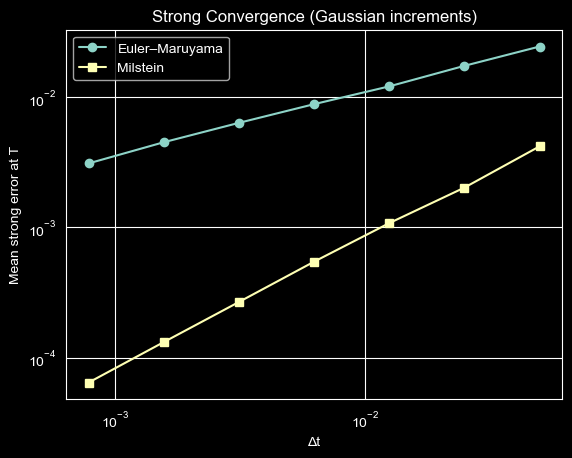

Strong slope (Euler–Maruyama): 0.4914379407023475
Strong slope (Milstein):       0.997919397502343


In [11]:
Ns = np.array([20, 40, 80, 160, 320, 640, 1280])

# Strong error curves
dt_e, err_e = strong_error_curve("euler", Ns, M=2000, noise_mode="gaussian")
dt_m, err_m = strong_error_curve("milstein", Ns, M=2000, noise_mode="gaussian")

# Plot strong convergence (Euler vs Milstein)
plt.figure()
plt.loglog(dt_e, err_e, marker="o", label="Euler–Maruyama")
plt.loglog(dt_m, err_m, marker="s", label="Milstein")
plt.xlabel("Δt")
plt.ylabel("Mean strong error at T")
plt.title("Strong Convergence (Gaussian increments)")
plt.legend()
plt.show()

print("Strong slope (Euler–Maruyama):", slope_loglog(dt_e, err_e))
print("Strong slope (Milstein):      ", slope_loglog(dt_m, err_m))

#### Weak Convergence (Gaussian Noise)

Weak convergence order is defined by how fast:

$$| \mathbb{E}[X_T^{\text{num}}] - \mathbb{E}[X_T^{\text{exact}}] |$$

decays as \(\Delta t \to 0\).

For Euler–Maruyama, weak order is 1 for many SDEs, including GBM.

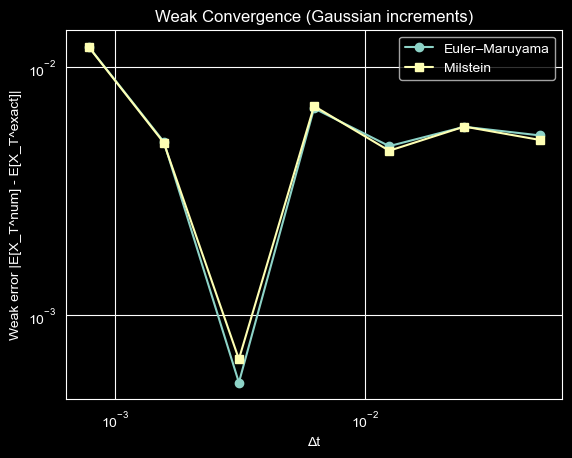

Weak slope (Euler–Maruyama): -7.712929348433984e-05
Weak slope (Milstein):       -0.018418730586169246


In [29]:
# Weak error curves (EM & Milstein)
dt_we, weak_err_e = weak_error_curve("euler", Ns, M=10_000)
dt_wm, weak_err_m = weak_error_curve("milstein", Ns, M=10_000)

plt.figure()
plt.loglog(dt_we, weak_err_e, marker="o", label="Euler–Maruyama")
plt.loglog(dt_wm, weak_err_m, marker="s", label="Milstein")
plt.xlabel("Δt")
plt.ylabel("Weak error |E[X_T^num] - E[X_T^exact]|")
plt.title("Weak Convergence (Gaussian increments)")
plt.legend()
plt.show()

print("Weak slope (Euler–Maruyama):", slope_loglog(dt_we, weak_err_e))
print("Weak slope (Milstein):      ", slope_loglog(dt_wm, weak_err_m))

In [30]:
cum_x

{20: [1.2052367133893291,
  1.1359503376547133,
  1.387129599895245,
  1.1807432573023284,
  1.1468520650917224,
  0.9729149094327705,
  1.1629916810631367,
  1.106869301623497,
  0.8680383458372295,
  0.8008735857853121,
  0.726265355058218,
  0.7914280453640214,
  0.8150268243557095,
  0.7200850408147434,
  0.7639578005065626,
  0.6740874095253384,
  0.7389004120129313,
  0.7577099160461028,
  0.7802029170389501,
  0.856001334726983],
 40: [1.0441311793879344,
  0.9751716817502104,
  0.9644269477713145,
  0.9941554780575279,
  1.0362950729215594,
  1.0059743822250458,
  0.932186463381561,
  1.033718677645929,
  1.01111657900905,
  0.9960740963670203,
  1.0166711148772898,
  0.9542903432920534,
  1.0699675016361552,
  1.0815478868599966,
  1.09610252901683,
  1.0841665306873995,
  0.9824450915404337,
  0.9269349242218508,
  0.930268937071746,
  0.8195612290869394,
  0.8136968905089218,
  0.876837463481094,
  0.9722059472278399,
  0.8816310187628562,
  0.9331675873996103,
  0.853784957

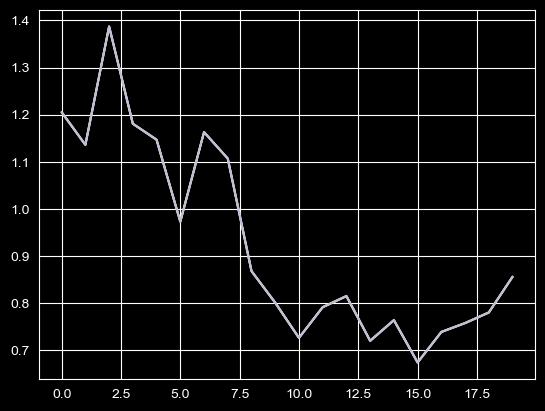

In [34]:
plt.plot(cum_x[20])
plt.show()

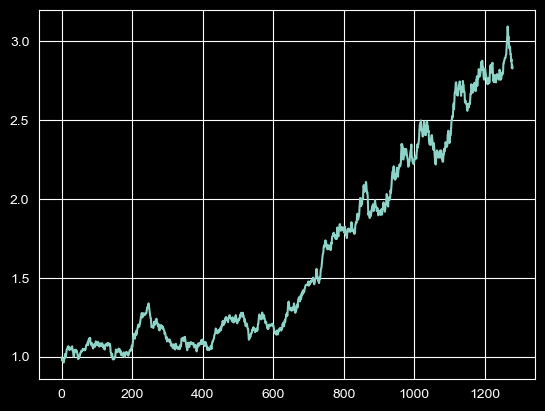

In [37]:
plt.plot(cum_x[1280])
plt.show()

In [36]:
max(cum_x)

1280

#### Runtime vs Accuracy

Table showing practical comparison of cost vs accuracy:
- Method (Euler vs Milstein)
- Number of steps N
- Step size Δt
- Strong error (mean over several paths)
- Runtime in seconds

In [13]:
runtime_df = runtime_accuracy_table(
    methods=("euler", "milstein"),
    Ns=(20, 40, 80, 160, 320, 640),
    M=400,   # number of paths per configuration
)

runtime_df

,Method,N steps,dt,Strong error (mean),Runtime (s)
0,euler,20,0.050000,0.024865,0.003832
1,euler,40,0.025000,0.018581,0.004312
2,euler,80,0.012500,0.012379,0.006954
3,euler,160,0.006250,0.008497,0.012657
4,euler,320,0.003125,0.006163,0.022848
5,euler,640,0.001563,0.004585,0.043749
6,milstein,20,0.050000,0.004000,0.003465
7,milstein,40,0.025000,0.002278,0.006478
8,milstein,80,0.012500,0.000945,0.011283
9,milstein,160,0.006250,0.000509,0.023279


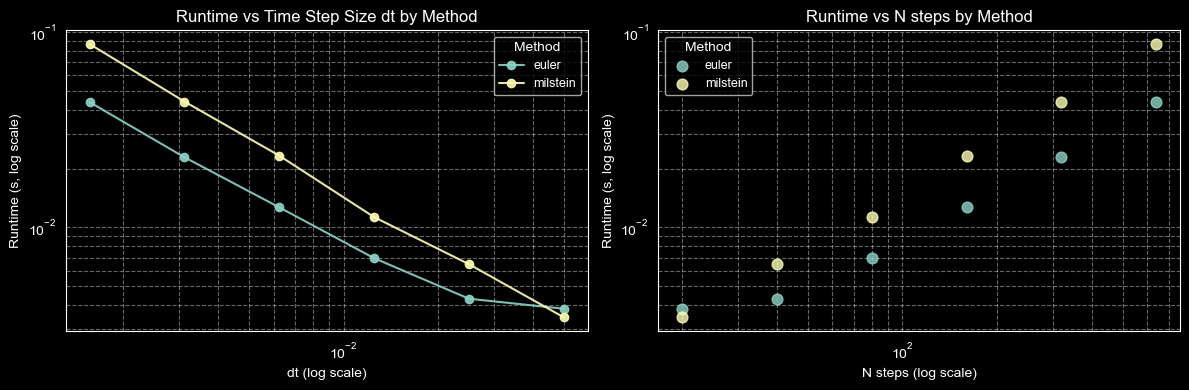

In [14]:
# Plot runtime vs accuracy
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Runtime vs dt ---
ax = axes[0]
for method, grp in runtime_df.groupby("Method"):
    grp_sorted = grp.sort_values("dt")
    ax.plot(
        grp_sorted["dt"],
        grp_sorted["Runtime (s)"],
        marker="o",
        linestyle="-",
        label=method,
        alpha=0.9,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("dt (log scale)")
ax.set_ylabel("Runtime (s, log scale)")
ax.set_title("Runtime vs Time Step Size dt by Method")
ax.grid(True, which="both", linestyle="--", alpha=0.4)
ax.legend(title="Method", fontsize=9)

# --- Runtime vs N steps ---
ax = axes[1]
for method, grp in runtime_df.groupby("Method"):
    ax.scatter(
        grp["N steps"],
        grp["Runtime (s)"],
        label=method,
        s=60,
        alpha=0.8,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("N steps (log scale)")
ax.set_ylabel("Runtime (s, log scale)")
ax.set_title("Runtime vs N steps by Method")
ax.grid(True, which="both", linestyle="--", alpha=0.4)
ax.legend(title="Method", fontsize=9)

fig.tight_layout()
plt.show()

### Skewed Increment Investigation

#### Noise Moments and Higher-Order Accuracy (Skewed Increments)

Investigate how **higher-order moments** (skewness, kurtosis) affect convergence:
1. Generate **skew-normal-like ΔW** with parameter __$alpha$__ controlling skewness.
2. Re-standardize to have mean ≈ 0, variance ≈ dt.
3. Estimate moment statistics for ΔW.
4. Recompute strong error curves for EM and Milstein with this skewed noise.

> Thoughts: for a true Brownian motion, increments are Gaussian. Using non-Gaussian
increments changes the **finite-Δt behavior**, which can degrade higher-order schemes.

In [15]:
# Examine increment moments under skew-normal noise
alpha = 6.0   # large alpha => noticeable skewness
dt_moment = 1e-3
rng_mom = np.random.default_rng(4242)

mean_skew, var_skew, skew_skew, ex_kurt_skew = sample_increment_moments(
    dt=dt_moment,
    rng=rng_mom,
    n=200_000,
    noise_mode="skewnormal",
    skew_alpha=alpha,
)

print("Skew-normal ΔW moments (dt = {})".format(dt_moment))
print("  mean          ≈", mean_skew)
print("  var           ≈", var_skew)
print("  skewness      ≈", skew_skew)
print("  excess kurtosis ≈", ex_kurt_skew)

Skew-normal ΔW moments (dt = 0.001)
  mean          ≈ 4.825433761061277e-05
  var           ≈ 0.0009957309860430712
  skewness      ≈ 0.8817181258357303
  excess kurtosis ≈ 0.7060987063437936


#### Strong Convergence (Skewed Increments)

Repeat strong error experiment, driving EM and Milstein with
**skew-normal increments** instead of Gaussian ones.

> Thoughts: This does not correspond to the original GBM SDE anymore (due to noise change),
but it shows how sensitive each scheme is to increment distribution shape at finite Δt.

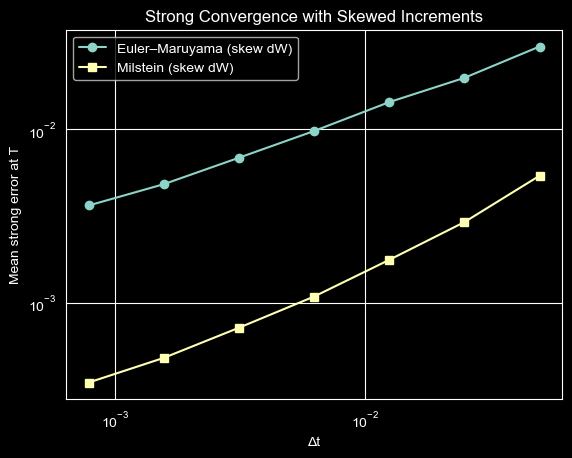

Strong slope (Euler–Maruyama, skew): 0.5095396615160961
Strong slope (Milstein, skew):       0.6562566053338023


In [16]:
# Strong error curves under skew-normal increments
dt_e_skew, err_e_skew = strong_error_curve(
    "euler",
    Ns,
    M=2000,
    noise_mode="skewnormal",
    skew_alpha=alpha,
)

dt_m_skew, err_m_skew = strong_error_curve(
    "milstein",
    Ns,
    M=2000,
    noise_mode="skewnormal",
    skew_alpha=alpha,
)

plt.figure()
plt.loglog(dt_e_skew, err_e_skew, marker="o", label="Euler–Maruyama (skew dW)")
plt.loglog(dt_m_skew, err_m_skew, marker="s", label="Milstein (skew dW)")
plt.xlabel("Δt")
plt.ylabel("Mean strong error at T")
plt.title("Strong Convergence with Skewed Increments")
plt.legend()
plt.show()

print("Strong slope (Euler–Maruyama, skew):", slope_loglog(dt_e_skew, err_e_skew))
print("Strong slope (Milstein, skew):      ", slope_loglog(dt_m_skew, err_m_skew))

#### *** Fixing Weak Convergence

Will ensure fair comparison with strong convergence by using common random numbers and a nested Brownian increment construction...

1. Using *common random numbers* across step sizes (nested Brownian increments)
2. Plotting weak error together with a Monte Carlo noise estimate (2*SE)
3. Showing weak error as a function of *number of Monte Carlo samples* M

In [17]:
# Helper functions

# GBM analytical benchmark for weak error: E[X_T]
def gbm_exact_mean(x0, mu, T):
    """
    For geometric Brownian motion:
        dX = mu X dt + sigma X dW
    the exact mean is:
        E[X_T] = x0 * exp(mu T)
    """
    return x0 * np.exp(mu * T)

# Statistical helper: estimate mean and standard error from samples
def weak_mean_and_se(terminals):
    """
    terminals: array of terminal values X_T^{(m)} across Monte Carlo samples m=1..M
    Returns:
      mu_hat = sample mean
      se     = standard error of the mean = s_hat / sqrt(M)
    """
    terminals = np.asarray(terminals)
    mu_hat = terminals.mean()
    s_hat = terminals.std(ddof=1)     # unbiased sample std dev
    se = s_hat / np.sqrt(terminals.size)
    return mu_hat, se

# Convenience: log-log slope estimate via least squares
def slope_loglog(xs, ys):
    """
    Estimate the slope in a log-log plot:
        slope ~ d log(ys) / d log(xs)
    Used for:
      - error vs dt (weak order)
      - error vs M (Monte Carlo rate ~ M^{-1/2})
    """
    xs = np.asarray(xs)
    ys = np.asarray(ys)
    mask = (xs > 0) & (ys > 0)
    lx = np.log(xs[mask])
    ly = np.log(ys[mask])
    A = np.vstack([lx, np.ones_like(lx)]).T
    m, _ = np.linalg.lstsq(A, ly, rcond=None)[0]
    return float(m)

In [18]:
# Common random numbers via nested Brownian increments

def make_nested_dWs(T, N_max, M, rng):
    """
    Generate fine Brownian increments for M independent paths on a fine grid of N_max steps.

    Returns:
      dW_f: shape (M, N_max), increments ~ N(0, dt_f)
      dt_f: fine time step = T / N_max
    """
    dt_f = T / N_max
    dW_f = rng.normal(0.0, np.sqrt(dt_f), size=(M, N_max))
    return dW_f, dt_f

def coarse_from_fine(dW_f, N_max, N):
    """
    Convert fine increments (N_max steps) into coarse increments (N steps) by summing blocks.

    Requires N_max % N == 0 so that the fine grid nests the coarse grid.

    Returns:
      dW_c: shape (M, N)
    """
    assert N_max % N == 0, "Need nested grids: N_max must be divisible by each N."
    m = N_max // N  # number of fine steps per one coarse step
    return dW_f.reshape(dW_f.shape[0], N, m).sum(axis=2)

In [19]:
# Evolve Euler / Milstein given a fixed increment matrix dWs

def simulate_terminals_from_dWs(method, dWs, dt):
    """
    Simulate terminal values for *many paths at once* using the same dt and provided dWs.

    Inputs:
      method: "euler" or "milstein"
      dWs: shape (M, N), Brownian increments for each path and step
      dt: time step = T/N

    Returns:
      terminals: shape (M,), terminal X_T values
    """
    M = dWs.shape[0]
    x = np.full(M, float(x0))

    if method == "euler":
        for n in range(dWs.shape[1]):
            x = euler_step(x, dt, dWs[:, n])

    elif method == "milstein":
        for n in range(dWs.shape[1]):
            x = milstein_step(x, dt, dWs[:, n])

    else:
        raise ValueError("method must be 'euler' or 'milstein'")

    return x

In [20]:
# Weak curve (error vs dt) with common random numbers + SE

def weak_curve_nested(method, Ns, N_max, M, seed=123):
    """
    Compute weak error curve using nested increments for common random numbers.

    For each N in Ns:
      - build coarse dW_c from the same fine increments dW_f
      - simulate M terminal values
      - compute weak error in mean and its Monte Carlo standard error

    Returns:
      dts:  array of dt values
      errs: array of |E_hat[X_T^{num}] - E[X_T]|
      ses:  array of standard errors for E_hat[X_T^{num}]
    """
    rng = np.random.default_rng(seed)
    exact = gbm_exact_mean(x0, mu, T)

    # Generate fine increments once; reuse for every N (common randomness)
    dW_f, _ = make_nested_dWs(T, N_max, M, rng)

    dts, errs, ses = [], [], []
    for N in Ns:
        dt = T / N
        dWs = coarse_from_fine(dW_f, N_max, N)

        terminals = simulate_terminals_from_dWs(method, dWs, dt)
        mu_hat, se = weak_mean_and_se(terminals)

        dts.append(dt)
        errs.append(abs(mu_hat - exact))
        ses.append(se)

    return np.array(dts), np.array(errs), np.array(ses)

def plot_weak_with_se(Ns, N_max, M, seed=123):
    """
    Plot weak error vs dt and also plot 2*SE vs dt to show the Monte Carlo noise floor.

    If |bias| is below ~2*SE, the weak convergence curve is dominated by sampling noise,
    so the slope will not show the theoretical weak order.
    """
    dt_e, err_e, se_e = weak_curve_nested("euler", Ns, N_max, M, seed=seed)
    dt_m, err_m, se_m = weak_curve_nested("milstein", Ns, N_max, M, seed=seed)

    plt.figure(figsize=(7, 5))

    # Bias estimate (absolute error of sample mean vs exact mean)
    plt.loglog(dt_e, err_e, "o-", label="Euler |bias|")
    plt.loglog(dt_m, err_m, "s-", label="Milstein |bias|")

    # Monte Carlo noise indicator (approx ~95% band for the mean if terminals are not too pathological)
    plt.loglog(dt_e, 2 * se_e, "o--", alpha=0.6, label="Euler 2·SE (MC noise)")
    plt.loglog(dt_m, 2 * se_m, "s--", alpha=0.6, label="Milstein 2·SE (MC noise)")

    plt.xlabel("dt")
    plt.ylabel(r"Weak error  $|\hat{E}[X_T^{num}] - E[X_T]|$")
    plt.title(f"Weak convergence with common random numbers (M={M}, N_max={N_max})")
    plt.grid(True, which="both", ls="--", alpha=0.3)
    plt.legend()
    plt.show()

    # Report the empirical slopes (purely diagnostic)
    print("Weak slope vs dt (Euler, nested):   ", slope_loglog(dt_e, err_e))
    print("Weak slope vs dt (Milstein, nested):", slope_loglog(dt_m, err_m))

In [21]:
# Error vs samples M (shows Monte Carlo rate ~ M^{-1/2})

def weak_error_vs_samples_nested(method, N, N_max, Ms, seed=999):
    """
    Fix a single N (time step) and vary M to show Monte Carlo convergence:
      |E_hat[X_T] - E[X_T]| ~ O(M^{-1/2})

    Uses nested increments as well.
    """
    rng = np.random.default_rng(seed)
    exact = gbm_exact_mean(x0, mu, T)
    dt = T / N

    errs, ses = [], []
    for M in Ms:
        dW_f, _ = make_nested_dWs(T, N_max, M, rng)
        dWs = coarse_from_fine(dW_f, N_max, N)

        terminals = simulate_terminals_from_dWs(method, dWs, dt)
        mu_hat, se = weak_mean_and_se(terminals)

        errs.append(abs(mu_hat - exact))
        ses.append(se)

    return np.array(Ms), np.array(errs), np.array(ses)

def plot_error_vs_samples(N, N_max, Ms, seed=999):
    """
    Plot weak mean error vs M and include a reference M^{-1/2} line.

    If the slope is near -0.5, it confirms you're seeing Monte Carlo sampling noise behavior.
    """
    Ms = np.asarray(Ms)

    M_e, err_e, se_e = weak_error_vs_samples_nested("euler", N, N_max, Ms, seed=seed)
    M_m, err_m, se_m = weak_error_vs_samples_nested("milstein", N, N_max, Ms, seed=seed)

    plt.figure(figsize=(7, 5))
    plt.loglog(M_e, err_e, "o-", label="Euler |error|")
    plt.loglog(M_m, err_m, "s-", label="Milstein |error|")

    # Reference line: c * M^{-1/2}, scaled to the first Euler point
    ref = err_e[0] * np.sqrt(Ms[0] / Ms)
    plt.loglog(Ms, ref, "k--", alpha=0.7, label=r"ref $\propto M^{-1/2}$")

    plt.xlabel("M (number of Monte Carlo samples)")
    plt.ylabel(r"$|\hat{E}[X_T] - E[X_T]|$")
    plt.title(f"Weak mean error vs samples (fixed N={N}, N_max={N_max})")
    plt.grid(True, which="both", ls="--", alpha=0.3)
    plt.legend()
    plt.show()

    print("Slope vs M (Euler):   ", slope_loglog(M_e, err_e))
    print("Slope vs M (Milstein):", slope_loglog(M_m, err_m))

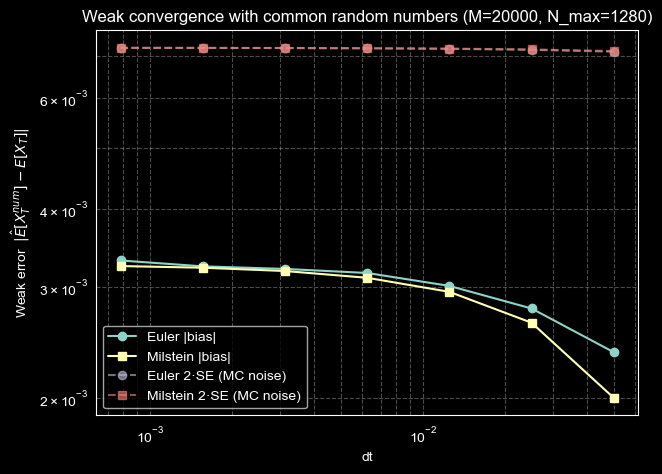

Weak slope vs dt (Euler, nested):    -0.07094155628453763
Weak slope vs dt (Milstein, nested): -0.09915340273344916


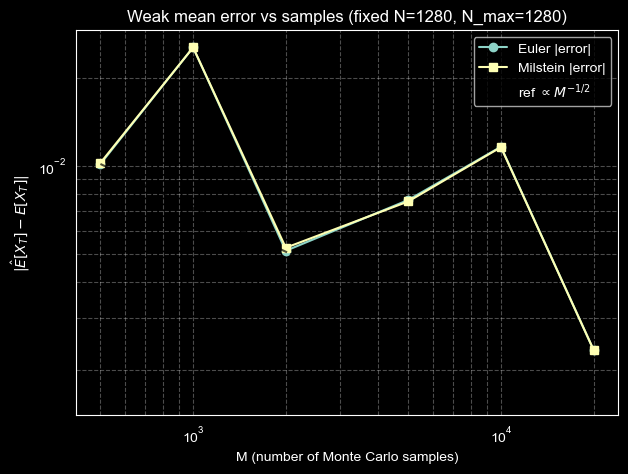

Slope vs M (Euler):    -0.34735662095069597
Slope vs M (Milstein): -0.3509555920819325


In [22]:
# Ns: time step counts for convergence curve
Ns = np.array([20, 40, 80, 160, 320, 640, 1280])

# N_max: fine grid used for nesting. Must be divisible by every N in Ns.
# Using max(Ns) works here because Ns are powers of two dividing 1280.
N_max = int(Ns.max())

# M: Monte Carlo sample size for the weak error vs dt plot.
# Increase M until the |bias| curves sit clearly above the 2*SE curves.
M = 20_000

plot_weak_with_se(Ns=Ns, N_max=N_max, M=M, seed=123)

# Ms: sample sizes for error-vs-samples plot
Ms = np.array([500, 1_000, 2_000, 5_000, 10_000, 20_000])

# Choose a fairly fine N so time-discretization bias is small (then the plot mainly shows MC behavior).
plot_error_vs_samples(N=1280, N_max=N_max, Ms=Ms, seed=999)